
# **Academic Integrity and Learning Statement**

By submitting my work, I confirm that:

- The code, analysis, and documentation in this notebook are my own work and reflect my own understanding.
- I am prepared to explain all code and analysis included in this submission.

If I used assistance (e.g., AI tools, tutors, or other resources), I have:

- Clearly documented where and how external tools or resources were used in my solution.
- Included a copy of the interaction (e.g., AI conversation or tutoring notes) in an appendix.

I acknowledge that:

- I may be asked to explain any part of my code or analysis during evaluation.
- Misrepresenting assisted work as my own constitutes academic dishonesty and undermines my learning.


# **Unit G: Advanced EDA**

#### **Introduction**
The goal of this unit is to perform a couple of advance data analysis steps to answer the following questions:
- What is the total number of samples by country ? Countries with very small sample size should be dropped from this analysis
- Count the number of organic and non-organic products in each country. Is there a country with a higher percentage of organic products ?
- Compare the distributions of the macronutrients between organic and non-organic products in each country.

#### **Table of content**
1) What is the total number of samples per country?
2) What is the percentage of organic products for each country?
3) Comparision in the distribution of macronutrients between organic and non organic products.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data_clean.csv")

/home/ruop/miniconda3/envs/adsml/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3441: DtypeWarning: Columns (1,43,45) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


### **Question 1: what is the total number of samples by country?**

Let's first compute the total number of samples per country, and then drop countries that have a small sample size.

In [4]:
# Compute the total number of samples per country
print(df.groupby("country").size())

country
CH      8237
DE      9504
FR        55
IT      2439
US    238824
dtype: int64


Let's remove France as it only has 55 different entries!

In [5]:
df = df[df["country"] != "FR"]

### **Question 2: What is the percentage of organic products for each country?

Let's start by creating a new column "organic" which says true or false depending on whether the product name contains "bio", "organic" or "eco".

In [6]:
df["organic"] = df.product_name_en.str.contains("organic|bio|eco", case=False, na=False)

print(df["organic"].sum(), "products are organic")

12207 products are organic


We can now count the number of organic and non organic product in each country and calculate the percentage of organic product per country:

In [7]:
print(df.groupby(["country", "organic"]).size())

country  organic
CH       False        7921
         True          316
DE       False        9484
         True           20
IT       False        2438
         True            1
US       False      226954
         True        11870
dtype: int64


In [8]:
# calculate the percentage of organic products per country
percent_organic = df.groupby("country")["organic"].sum() / df.groupby("country").size()

print(percent_organic)

country
CH    0.038363
DE    0.002104
IT    0.000410
US    0.049702
dtype: float64


It looks like around 3-6 % of products are organic in the US and in switzerland, and a lot less in germany and italy. This could however come from different ways of naming products. I also had a look if the ingredient list contains bio or organic, but this still necessarily wouldn't make a product organic as it can contain both organic and non organic ingredients (and would then be not organic). 

### **Question 3: compare the distributions of macronutrients between organic and non-organic products**

To answer this question, I will start by creating four lists with the information about the macronutrients for each country (US, CH, IT and DE). I will then plot the data using a violin plot

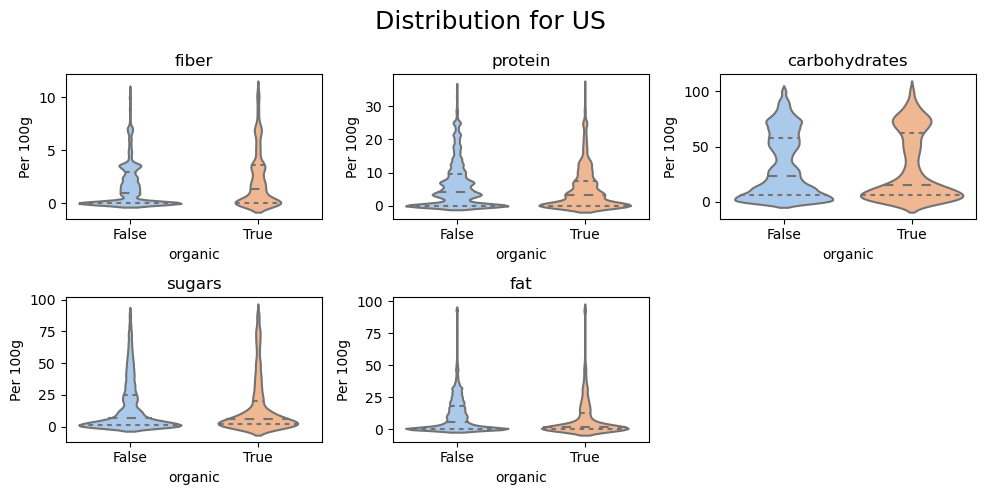

In [10]:
# create four lists with the info for each country
df_US = df[df["country"] == "US"]
df_CH = df[df["country"] == "CH"]
df_IT = df[df["country"] == "IT"]
df_DE = df[df["country"] == "DE"]

macro_cols = ["fiber_per_hundred", "protein_per_hundred", "carbohydrates_per_hundred", "sugars_per_hundred", "fat_per_hundred"]

# Violin plot for the US
fig, axes = plt.subplots(2, 3, figsize=(10,5))
axes = axes.flatten()
for col, ax in zip(macro_cols, axes):
    sns.violinplot(data=df_US, y=col, x="organic", ax=ax, inner="quart", palette = "pastel")
    ax.set_title(col.replace('_per_hundred', ''))
    ax.set_ylabel("Per 100g")

# Hide the extra subplot
axes[-1].set_visible(False)
plt.suptitle("Distribution for US", fontsize=18)
plt.tight_layout()
plt.show()


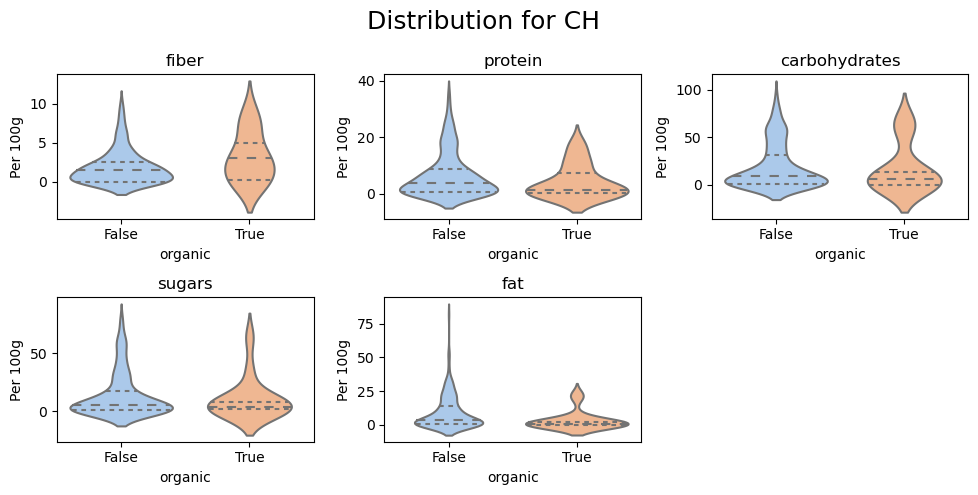

In [12]:
# Violin plot for Switzerland
fig, axes = plt.subplots(2, 3, figsize=(10,5))
axes = axes.flatten()
for col, ax in zip(macro_cols, axes):
    sns.violinplot(data=df_CH, y=col, x="organic", ax=ax, inner="quart", palette = "pastel")
    ax.set_title(col.replace('_per_hundred', ''))
    ax.set_ylabel("Per 100g")

# Hide the extra subplot
axes[-1].set_visible(False)
plt.suptitle("Distribution for CH", fontsize=18)
plt.tight_layout()

I only plotted the data for switzerland and the US as they are the two contries with the most entries. No clear difference jumps out from these graphs. It could now be interesting to do a statistical test on some of these variables to see if they are different between organic and non-organic foods.  

I will now try another way to plot the data using seaborn violin plots (split according to organic / non-organic with "hue". 

I will only try this for the US data. To do this, I need to have the data in a long format, with one column containing organic vs non-organic, one column with the different macronutrients (x axis) and one column with the values. 

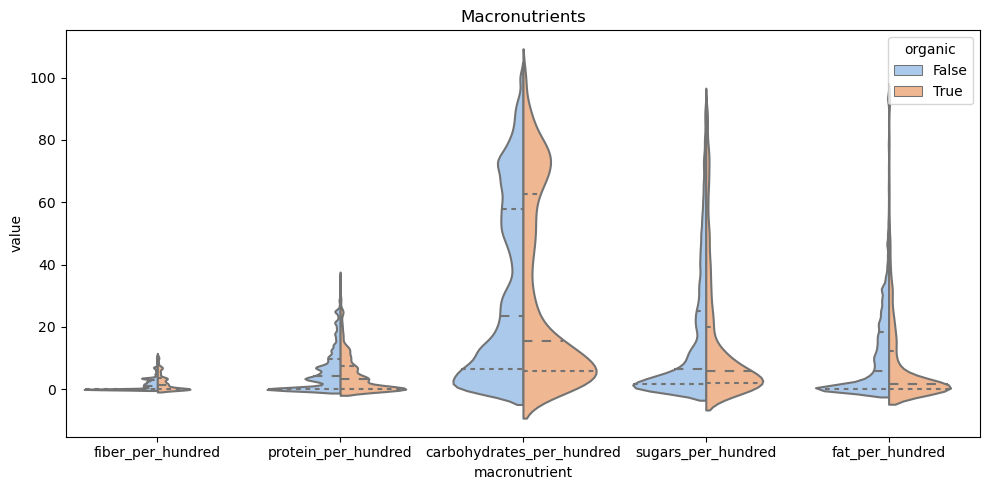

In [16]:
### trying out another way to plot the data. 
df_US_subset = df_US[macro_cols + ["organic"]]

df_US_subset = df_US_subset.melt(id_vars="organic", value_vars=macro_cols, var_name="macronutrient")

plt.figure(figsize=(10,5))
sns.violinplot(data = df_US_subset, x="macronutrient", y="value", hue="organic", split=True, palette="pastel", inner="quart")
plt.title("Macronutrients")
plt.tight_layout()
plt.show()

This allows us to better see some differences between the distributions. It becomes apparent that organic products have less carbohydrates and fat than non-organic products for instance.